In [2]:
import pandas as pd
from sklearn.metrics import f1_score
from transformers import GPT2LMHeadModel, GPT2TokenizerFast, T5ForConditionalGeneration, T5Tokenizer
import torch
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [2]:
def get_log_prob(text, model, tokenizer, device):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
    # outputs.loss is mean negative log-likelihood
    return -outputs.loss.item() * inputs["input_ids"].shape[1]  # total log-prob


def perturb_text(text, mask_tokenizer, mask_model, device, mask_ratio=0.15, n_perturbations=10):
    """Randomly mask spans and infill with T5."""
    words = text.split()
    perturbed = []

    for _ in range(n_perturbations):
        masked_words = words.copy()
        n_masks = max(1, int(len(words) * mask_ratio))
        mask_indices = np.random.choice(len(words), n_masks, replace=False)

        sentinel = 0
        for idx in sorted(mask_indices):
            masked_words[idx] = f"<extra_id_{sentinel}>"
            sentinel += 1

        masked_text = " ".join(masked_words)
        inputs = mask_tokenizer(masked_text, return_tensors="pt", truncation=True).to(device)

        with torch.no_grad():
            output = mask_model.generate(
                inputs["input_ids"],
                max_new_tokens=50,
                do_sample=True,
                top_p=0.96,
                temperature=1.0
            )

        filled = mask_tokenizer.decode(output[0], skip_special_tokens=True)
        perturbed.append(filled)

    return perturbed


def detectgpt_score(text, score_model, score_tokenizer, mask_model, mask_tokenizer, device, n_perturbations=5):
    original_log_prob = get_log_prob(text, score_model, score_tokenizer, device)
    perturbations = perturb_text(text, mask_tokenizer, mask_model, device, n_perturbations=n_perturbations)
    perturbed_log_probs = [get_log_prob(p, score_model, score_tokenizer, device) for p in perturbations]
    return original_log_prob - np.mean(perturbed_log_probs)  # high → LLM-generated

def get_perplexity(text, model, tokenizer, device):
    """Reuses get_log_prob — PPL = exp(mean NLL)"""
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
    return torch.exp(outputs.loss).item()  # PPL = exp(mean NLL)


def get_cross_perplexity(text, observer_model, observer_tokenizer,
                               performer_model, performer_tokenizer, device):
    """
    CrossPPL: cross-entropy between performer soft labels and observer log-probs.
    Measures how surprising the text is to observer, weighted by performer beliefs.
    """
    observer_inputs = observer_tokenizer(
        text, return_tensors="pt", truncation=True, max_length=512
    ).to(device)
    performer_inputs = performer_tokenizer(
        text, return_tensors="pt", truncation=True, max_length=512
    ).to(device)

    with torch.no_grad():
        observer_log_probs = torch.log_softmax(
            observer_model(**observer_inputs).logits, dim=-1
        )
        performer_probs = torch.softmax(
            performer_model(**performer_inputs).logits, dim=-1
        )

    # Shift: predict token t+1 from context 0..t
    ce = -(performer_probs[:, :-1] * observer_log_probs[:, 1:]).sum(dim=-1)
    return torch.exp(ce.mean()).item()


def binoculars_score(text, observer_model, observer_tokenizer,
                          performer_model, performer_tokenizer, device):
    """
    Binoculars = PPL_observer / CrossPPL(observer, performer)
    Low score → AI | High score → Human
    """
    ppl = get_perplexity(text, observer_model, observer_tokenizer, device)
    cross_ppl = get_cross_perplexity(
        text,
        observer_model, observer_tokenizer,
        performer_model, performer_tokenizer,
        device
    )
    return ppl / cross_ppl


In [3]:
# --- Setup ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")  # use Apple Silicon GPU

# Scoring model: lightweight GPT2 base (117M vs 1.5B for xl)
score_model_name = "gpt2"
score_tokenizer = GPT2TokenizerFast.from_pretrained(score_model_name)
score_model = GPT2LMHeadModel.from_pretrained(score_model_name).to(device)
score_model.eval()

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12615.22it/s]


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [4]:
from sklearn.model_selection import train_test_split

data = pd.read_csv('data/clean_data/kaggle_dataset.csv')

# Keep only N texts per class
N = 200

df = data.groupby("generated").sample(n=N, random_state=42)

# Split into val (threshold calibration) and test (final evaluation)
df_val, df_test = train_test_split(
    df,
    test_size=0.5,        # 100 val + 100 test per class
    stratify=df["generated"],
    random_state=42
)

texts_val  = df_val["text"].tolist()
labels_val = df_val["generated"].tolist()

texts_test  = df_test["text"].tolist()
labels_test = df_test["generated"].tolist()

print(f"Val:  {len(texts_val)} texts")
print(f"Test: {len(texts_test)} texts")

Val:  200 texts
Test: 200 texts


### Basic Benchmarck

In [5]:
# Zero effort, should always be beaten
preds_majority = np.ones(len(labels_val))  # always predict AI
basic_benchmark = accuracy_score(labels_val, preds_majority)
print(basic_benchmark)

0.5


### Simple Benchmark

In [59]:
# Just use raw GPT2 log-prob without perturbations
# You already compute this in get_log_prob() — free to add
log_probs = [get_log_prob(t, score_model, score_tokenizer, device)
             for t in texts_val]
scaler = MinMaxScaler()
scaled_log_probs = scaler.fit_transform(
    np.array(log_probs).reshape(-1, 1)
).flatten()


In [60]:
# We calibrate the threshold on the validation set
# Try all possible thresholds
thresholds = np.linspace(0, 1, 200)

f1_scores = []
for t in thresholds:
    preds = (scaled_log_probs > t).astype(int)  # above threshold → AI
    f1_scores.append(f1_score(labels_val, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold:.4f} | Best F1: {max(f1_scores):.4f}")

Best threshold: 0.4673 | Best F1: 0.7860


In [61]:
#Test set performance
log_probs_test = [get_log_prob(t, score_model, score_tokenizer, device)
             for t in texts_test]
scaled_log_probs_test = scaler.transform(
    np.array(log_probs_test).reshape(-1, 1)
).flatten()
preds = (scaled_log_probs_test > best_threshold).astype(int)
print(f"Log Probability Accuracy: {accuracy_score(labels_test, preds):.4f}")
print(f"Log Probability AUROC: {roc_auc_score(labels_test, scaled_log_probs_test):.4f}")

Log Probability Accuracy: 0.7350
Log Probability AUROC: 0.7488


### Strong Benchmark - zero-shot perplexity

In [9]:
perplexities = np.array([
    np.exp(-get_log_prob(t, score_model, score_tokenizer, device) / len(t.split()))
    for t in texts_val
])

# Search over actual perplexity range
thresholds = np.linspace(perplexities.min(), perplexities.max(), 200)

f1_scores = []
for t in thresholds:
    preds = (perplexities < t).astype(int)  # low perplexity → AI (1)
    f1_scores.append(f1_score(labels_val, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold:.4f} | Best F1: {max(f1_scores):.4f}")

# Apply on test set
perplexities_test = np.array([
    np.exp(-get_log_prob(t, score_model, score_tokenizer, device) / len(t.split()))
    for t in texts_test
])
preds_test = (perplexities_test < best_threshold).astype(int)
print(f"Test Accuracy: {accuracy_score(labels_test, preds_test):.4f}")
print(f"Test AUROC:    {roc_auc_score(labels_test, -perplexities_test):.4f}")

Best threshold: 48.3827 | Best F1: 0.6696
Test Accuracy: 0.6150
Test AUROC:    0.7011


### DetectGPT

In [10]:
# Perturbation model: t5-small (60M vs 770M for large)
mask_model_name = "t5-small"
mask_tokenizer = T5Tokenizer.from_pretrained(mask_model_name)
mask_model = T5ForConditionalGeneration.from_pretrained(mask_model_name).to(device)
mask_model.eval()

# Compute DetectGPT scores on val set
detectgpt_scores_val = np.array([
    detectgpt_score(t, score_model, score_tokenizer, mask_model, mask_tokenizer, device)
    for t in texts_val
])

# Fit scaler on val only
scaler = MinMaxScaler().fit(detectgpt_scores_val.reshape(-1, 1))
detectgpt_probs_val = scaler.transform(detectgpt_scores_val.reshape(-1, 1)).flatten()

# Calibrate threshold on val by maximizing F1
thresholds = np.linspace(0, 1, 200)
f1_scores = []
for t in thresholds:
    preds = (detectgpt_probs_val > t).astype(int)  # high score → AI
    f1_scores.append(f1_score(labels_val, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold:.4f} | Val F1: {max(f1_scores):.4f}")

# Apply on test set using SAME scaler
detectgpt_scores_test = np.array([
    detectgpt_score(t, score_model, score_tokenizer, mask_model, mask_tokenizer, device)
    for t in texts_test
])
detectgpt_probs_test = scaler.transform(detectgpt_scores_test.reshape(-1, 1)).flatten()

preds_test = (detectgpt_probs_test > best_threshold).astype(int)
print(f"DetectGPT Accuracy: {accuracy_score(labels_test, preds_test):.4f}")
print(f"DetectGPT AUROC:    {roc_auc_score(labels_test, detectgpt_probs_test):.4f}")

Loading weights: 100%|██████████| 131/131 [00:00<00:00, 6240.74it/s]


Best threshold: 0.4673 | Val F1: 0.7913
DetectGPT Accuracy: 0.7350
DetectGPT AUROC:    0.7517


### Binoculars

In [26]:
# Load observer + performer
observer_model_name  = "gpt2"
performer_model_name = "gpt2-medium"

observer_tokenizer  = GPT2TokenizerFast.from_pretrained(observer_model_name)
observer_model      = GPT2LMHeadModel.from_pretrained(observer_model_name).to(device)
observer_model.eval()

performer_tokenizer = GPT2TokenizerFast.from_pretrained(performer_model_name)
performer_model     = GPT2LMHeadModel.from_pretrained(performer_model_name).to(device)
performer_model.eval()

# Compute scores on val set
bino_scores_val = np.array([
    binoculars_score(t, observer_model, observer_tokenizer,
                        performer_model, performer_tokenizer, device)
    for t in texts_val
])

# Fit scaler on val only (invert: low score → AI → high prob)
scaler_bino = MinMaxScaler().fit((-bino_scores_val).reshape(-1, 1))
bino_probs_val = scaler_bino.transform((-bino_scores_val).reshape(-1, 1)).flatten()

# Calibrate threshold by maximizing F1 on val
thresholds = np.linspace(bino_scores_val.min(), bino_scores_val.max(), 200)
f1_scores = []
for t in thresholds:
    preds = (bino_scores_val < t).astype(int)  # below threshold → AI
    f1_scores.append(f1_score(labels_val, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold:.4f} | Val F1: {max(f1_scores):.4f}")

# Apply on test set using SAME scaler
bino_scores_test = np.array([
    binoculars_score(t, observer_model, observer_tokenizer,
                        performer_model, performer_tokenizer, device)
    for t in texts_test
])
bino_probs_test = scaler_bino.transform((-bino_scores_test).reshape(-1, 1)).flatten()

preds_test = (bino_scores_test < best_threshold).astype(int)
print(f"Binoculars Accuracy: {accuracy_score(labels_test, preds_test):.4f}")
print(f"Binoculars AUROC:    {roc_auc_score(labels_test, bino_probs_test):.4f}")

Loading weights: 100%|██████████| 292/292 [00:00<00:00, 8939.81it/s]


Best threshold: 0.0022 | Val F1: 0.7964
Binoculars Accuracy: 0.7300
Binoculars AUROC:    0.8745


In [72]:
# Text I wrote for the report
t = "We implement several state-of-art zero-shot detection model, namely DetectGPT and Binoculars. By definition these models do not need to be trained on a proper training set, it only requiers to calibrate the classification threshold on a validation set. In a production setting, we can thing of adjusting the threshold in a dynamic manner depending on the texts analyzed so far. Like in the online learning theory, the updated threshold should converge to the best threshold assuming a large sample of texts."

In [73]:
# Ask GPT 5-3 to rewrite it
t_gpt = "all methods perform above random chance, but with significant differences in ranking quality. Binoculars clearly dominates the other approaches, indicating that cross-model disagreement provides a stronger detection signal than either raw likelihood or perturbation-based scoring. DetectGPT and log-probability perform similarly, suggesting that perturbation-based curvature provides only a marginal gain over single-model likelihood. Perplexity yields the weakest performance among the baselines. Moreover, the main distinction between methods is not only the absolute AUC values, but also the steepness of the ROC curve at low false-positive rates, which is critical in practical detection settings where false positives must be minimized."


In [74]:
vect = [t, t_gpt]
bino_scores_test = np.array([
    binoculars_score(t, observer_model, observer_tokenizer,
                        performer_model, performer_tokenizer, device)
    for t in vect
])
bino_probs_test = scaler_bino.transform((-bino_scores_test).reshape(-1, 1)).flatten()

preds_test = (bino_scores_test < best_threshold).astype(int)
print(f"Binoculars predicts the Human written test to be : {'Human' if preds_test[0] == 0 else 'LLM-generated'}")
print(f"Binoculars predicts the GPT 5.3 rewritten test to be : {'Human' if preds_test[1] == 0 else 'LLM-generated'}")

Binoculars predicts the Human written test to be : LLM-generated
Binoculars predicts the GPT 5.3 rewritten test to be : LLM-generated


### Results Analysis

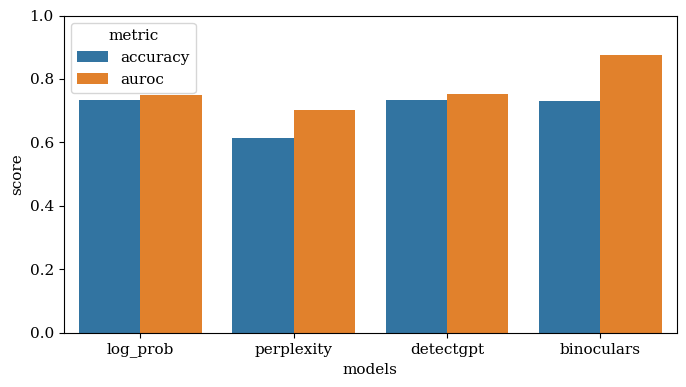

In [63]:
#Models Accuracy
accuracy_df = pd.DataFrame({
    'accuracy': [0.7350, 0.6150, 0.7350, 0.73],
    'models': ['log_prob', 'perplexity', 'detectgpt', 'binoculars']
})

auroc_df = pd.DataFrame({
    'auroc': [0.7488, 0.7011,  0.7517, 0.8745],
    'models': ['log_prob', 'perplexity', 'detectgpt', 'binoculars']
})

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 11
plt.rcParams["figure.facecolor"] = "white"

df = accuracy_df.merge(auroc_df, on="models")
df = df.melt(id_vars="models", var_name="metric", value_name="score")

plt.figure(figsize=(7,4))
sns.barplot(data=df, x="models", y="score", hue="metric")

plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("detection_methods_comparison.png")
plt.show()


/var/folders/mh/pjql7z356jb4v12kd0zhljs40000gn/T/ipykernel_71344/1510148194.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title="Class")
/var/folders/mh/pjql7z356jb4v12kd0zhljs40000gn/T/ipykernel_71344/1510148194.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title="Class")
/var/folders/mh/pjql7z356jb4v12kd0zhljs40000gn/T/ipykernel_71344/1510148194.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title="Class")
/var/folders/mh/pjql7z356jb4v12kd0zhljs40000gn/T/ipykernel_71344/1510148194.py:31: UserWarning: No artists with labels found to put in legend.  N

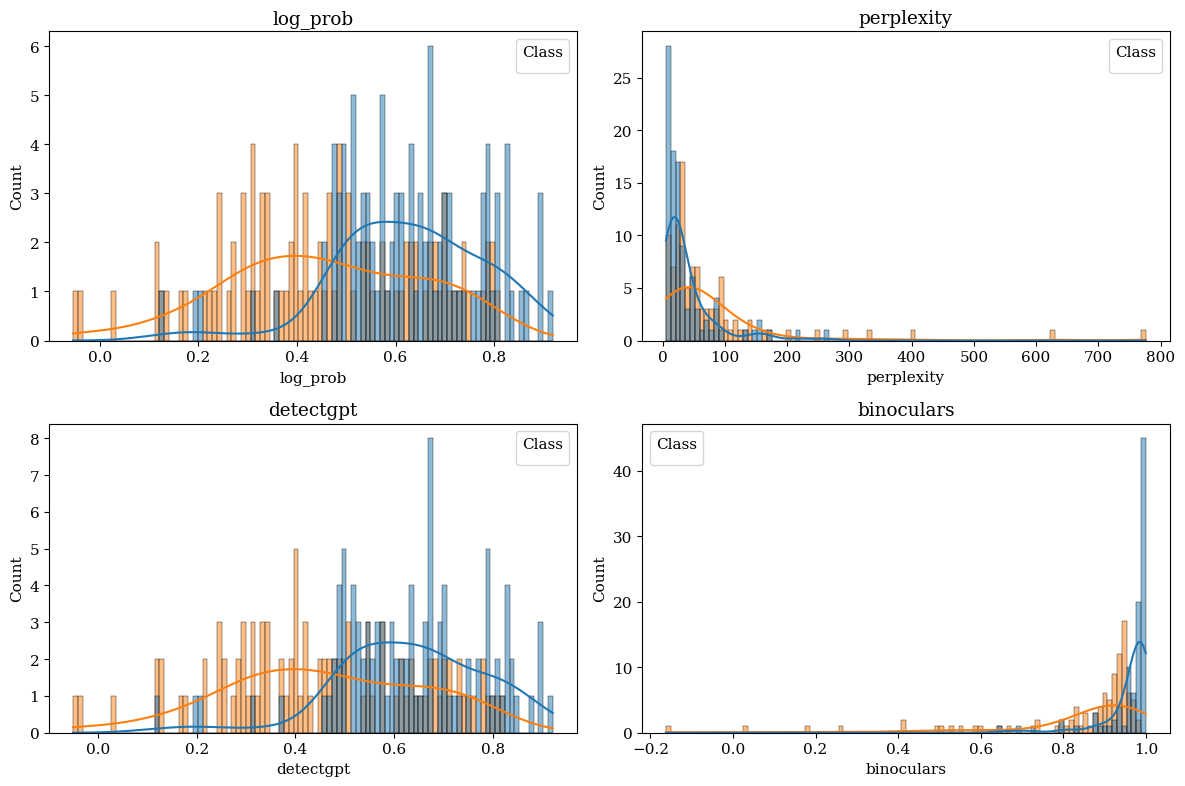

In [64]:
scores = pd.DataFrame({
    "log_prob": scaled_log_probs_test,
    "perplexity": perplexities_test,
    "detectgpt": detectgpt_probs_test,
    "binoculars": bino_probs_test,
    "label": labels_test
})
label_map = {0: "Human", 1: "AI"}
scores["label"] = scores["label"].map(label_map)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 11
plt.rcParams["figure.facecolor"] = "white"

features = ['log_prob', 'perplexity', 'detectgpt', 'binoculars']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, m in enumerate(features):
    sns.histplot(
        data=scores,
        x=m,
        hue="label",
        bins=100,
        alpha=0.5,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(m)
    axes[i].legend(title="Class")

plt.tight_layout()
plt.savefig("score_distrib_per_class.png")
plt.show()

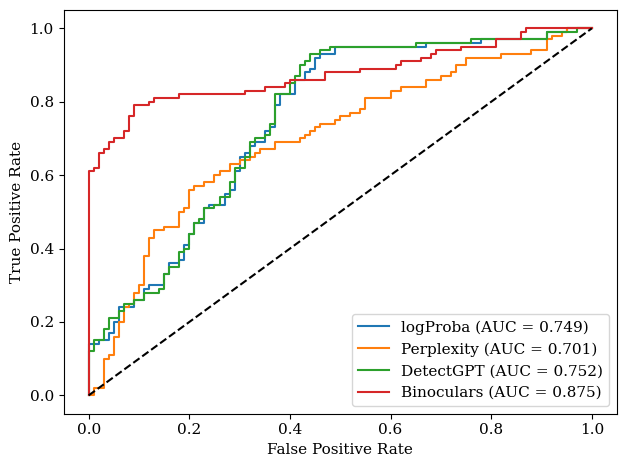

In [65]:
from sklearn.metrics import roc_curve, auc

def plot_roc(scores, labels, name):
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")


plt.figure()

plot_roc(scaled_log_probs_test, labels_test,  "logProba")
plot_roc(-perplexities_test, labels_test, "Perplexity")
plot_roc(detectgpt_scores_test, labels_test, "DetectGPT")
plot_roc(-bino_scores_test, labels_test, "Binoculars")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.show()